# Qubit Spectroscopy Analysis
Load `ds_raw.h5` from a qubit-spectroscopy run and extract peak positions
using `QubitSpectroscopyAnalyzer`.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.protocols.qubit_spectroscopy import QubitSpectroscopyAnalyzer
from scqat.parsers.qualibrate_parser import repetition_data


## 1. Configuration

In [2]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\#3817_LCH_qubit_spectroscopy_214800"

DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")
FIGURE_SAVE_PATH = os.path.join(DATA_FOLDER, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

## 2. Load Dataset

In [3]:
dataset = load_xarray_h5(DS_RAW_PATH)
# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]
# Combine I and Q into complex IQdata
sq_data["IQdata"] = sq_data["I"] + 1j * sq_data["Q"]


## 3. Run Analyzer

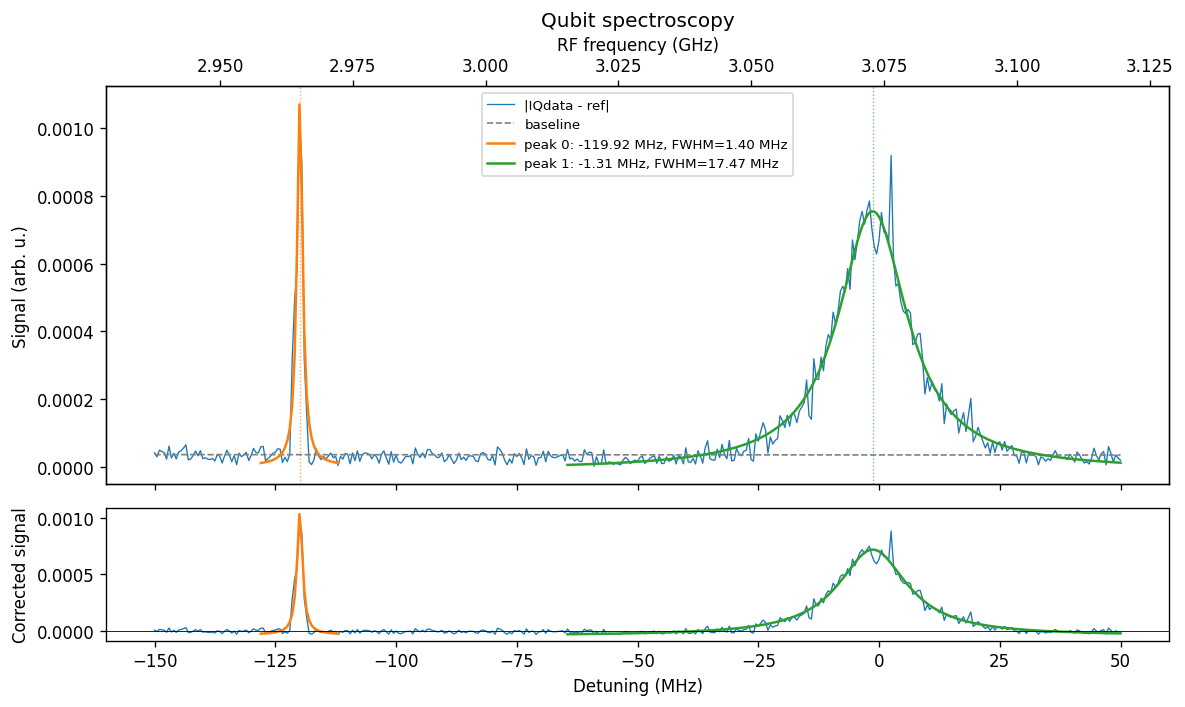

In [4]:
analyzer = QubitSpectroscopyAnalyzer()
results, figs = analyzer.analyze(sq_data, output_dir=FIGURE_SAVE_PATH, max_peaks=2)

## 4. Display Figures

In [5]:
for name, fig in figs.items():
    fig.show()

C:\Users\shiau\AppData\Local\Temp\ipykernel_55884\1076532957.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


## 5. Peak Summary Table

In [6]:
if results['ref_iq'] is not None:
    print(f"IQ reference point: {results['ref_iq']}")
print(f"Peaks found: {len(results['peaks'])}")
for i, pk in enumerate(results['peaks']):
    print(f"\nPeak {i}:")
    print(f"  Detuning: {pk['detuning']/1e6:.4f} MHz")
    print(f"  FWHM:     {pk['fwhm']/1e6:.4f} MHz")
    print(f"  Amplitude: {pk['amplitude']:.6f}")
    if 'full_freq' in pk:
        print(f"  Abs freq: {pk['full_freq']/1e9:.6f} GHz")

IQ reference point: (-0.0011223430442810058-0.0006644765281677246j)
Peaks found: 2

Peak 0:
  Detuning: -119.9177 MHz
  FWHM:     1.4022 MHz
  Amplitude: 0.001083
  Abs freq: 2.958665 GHz

Peak 1:
  Detuning: -1.3085 MHz
  FWHM:     17.4671 MHz
  Amplitude: 0.000765
  Abs freq: 3.077274 GHz
